#  Problem set 3
In this assignment, you will explore the effect of dimensionality reduction and probabilistic modeling through hands-on implementation and analysis. You will begin by learning the fundamentals of Principal Component Analysis (PCA), a key technique used to reduce the dimensionality of data while preserving as much variance as possible. You will implement PCA from scratch, understanding how to transform neural data in **problem set 1** (Neural prosthetic decoding) into a lower-dimensional space effectively.

Following this, you will delve into model selection to determine the optimal number of components for PCA, using techniques such as the elbow method to evaluate the trade-off between dimensionality and the amount of variance explained. This understanding is crucial for making informed decisions when applying PCA to real-world data.

The assignment will culminate in an exploration of Probabilistic Principal Component Analysis (PPCA), an extension of PCA that models the data with a probabilistic framework. You will implement PPCA using the Expectation-Maximization (EM) algorithm, gaining insight into how this iterative method estimates the latent variables and model parameters, and comparing its performance to traditional PCA. Through these tasks, you will develop a comprehensive understanding of PCA and PPCA, equipping you with valuable skills applicable in various data science and machine learning contexts.



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as scio
import seaborn as sns

## load and preprocess data

# load data

dataset = scio.loadmat('ps1_realdata.mat')
train_trials = dataset['train_trial']
test_trials = dataset['test_trial']

# get the dimensions

def preprocess_data(x):

    n_trials, n_angles = x.shape 
    n_neurons = x[0, 0]['spikes'].shape[0]

    return np.array([[[x[n,k][1][i,350:550].sum() for i in range(n_neurons)] for k in range(n_angles)] for n in range(n_trials)])

# preprocess data
train_data = preprocess_data(train_trials)
test_data = preprocess_data(test_trials)
print("training data shape: ",train_data.shape)
print("test data shape: ",test_data.shape)

# make the label

label = np.zeros([train_data.shape[0],train_data.shape[1]],dtype=np.int16)

for k in range(train_data.shape[1]):
    label[:,k] = k 

# combine the first two dimensions into n_samples

label = np.concatenate(label,0)
train_data = np.concatenate(train_data,0)
test_data = np.concatenate(test_data,0)

print(f"The number of training data is {train_data.shape[0]}, feature dimension of training data is {train_data.shape[1]}")
print(f"The number of training data is {test_data.shape[0]}, feature dimension of training data is {test_data.shape[1]}")



# Part 1. PCA

In this part, you are tasked with implementing the Principal Component Analysis (PCA) algorithm from scratch to understand its underlying mechanics and applications in dimensionality reduction. PCA is a powerful statistical technique used to identify the main axes of variance in high-dimensional datasets, allowing for a more efficient representation of the data in a lower-dimensional space. By decomposing the data into orthogonal components, PCA not only reduces computational complexity but also helps in noise reduction and feature extraction. 

## **(35 pts)** PCA algorithm 

Your goal is to derive and implement the PCA algorithm using numpy, and apply it to visualize patterns within an example dataset. This process will involve standardizing the data, calculating the covariance matrix, and performing eigen decomposition. Analyzing the variance explained by each principal component and visualizing the results will provide insights into the structure of the data.

In [4]:
class PCA:

    """
    Implement the PCA algorithm to reduce the dimensionality of data X to num_components.

    Parameters:
    X: The input data matrix, where each row represents a sample.
    num_components: The number of principal components to retain.

    Attributes:
    projected_data: The projected data in the reduced-dimensional space.
    components: The principal component vectors.
    explained_variance: The proportion of variance explained by each of the principal components.
    """
    def __init__(self,num_components):

        self.num_components = num_components
        self.eigenvalues = []
        self.eigenvectors = []

        self.components = []
        self.sorted_indices = []
        self.explained_variance_ratio_ = []


    def fit(self,X):

        # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

        # 1. Standardize the data: Subtract the mean from each feature.
        X_centered = X - np.mean(X, axis=0)

        # 2. Compute the covariance matrix.
        cov_matrix = np.cov(X_centered, rowvar=False)

        # 3. Compute the eigenvalues and eigenvectors of the covariance matrix.
        # you can use np.linalg.eigh()
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # 4. Sort the eigenvectors by descending eigenvalues.
        self.sorted_indices = np.argsort(eigenvalues)[::-1]
        self.eigenvalues = eigenvalues[self.sorted_indices]
        self.eigenvectors = eigenvectors[:, self.sorted_indices]

        # 5. Select the topK num_components eigenvectors.
        self.components = self.eigenvectors[:, :self.num_components]

        # 6. Compute the explained variance.
        total_variance = np.sum(eigenvalues)
        self.explained_variance_ratio_ = self.eigenvalues[:self.num_components] / total_variance

        # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
        pass

    def transform(self,X):
        projected_data = []

        # 1. Standardize the data: Subtract the mean from each feature.
        X_centered = X - np.mean(X, axis=0)

        # 2. Project the data onto the reduced space.
        projected_data = np.dot(X_centered, self.components)

        return projected_data



def visualize_projection(original_data, projected_data,label):
    """
    Visualize the projected low-dimensional data.

    Parameters:
    original_data: The original high-dimensional data.
    projected_data: The data after dimensionality reduction.
    """

    plt.figure(figsize=(8, 6))
    # define color_set
    color_set = sns.color_palette('dark',n_colors=8)

    # Plot original data
    plt.subplot(1, 2, 1)
    for angle in np.unique(label):
        mask = label == angle
        plt.scatter(original_data[mask, 0], original_data[mask, 1], color=color_set[angle],alpha=0.5, label='Original Data') #Corrected label
    plt.title('Original Data')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True)

    # Plot projected data
    plt.subplot(1, 2, 2)
    # Assuming projected data has been reduced to 2D for visualization
    for angle in np.unique(label):
        mask = label == angle
        plt.scatter(projected_data[mask, 0], projected_data[mask, 1], color=color_set[angle],alpha=0.5, label='Projected Data')
    plt.title('Projected Data')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

## Call the PCA and visualization function

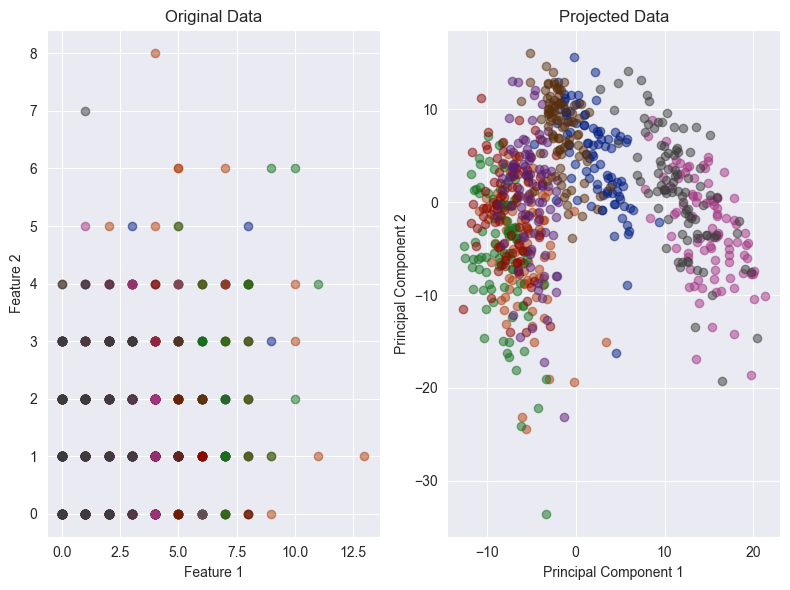

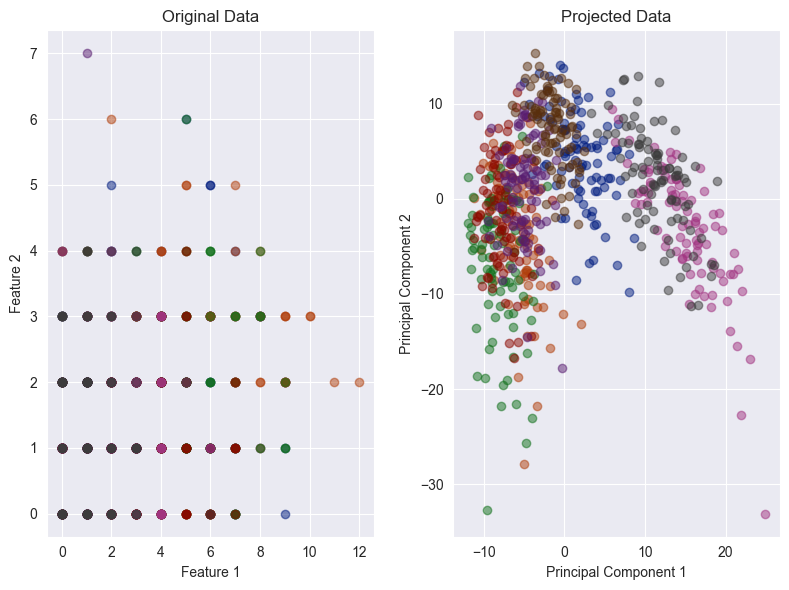

In [5]:
pca = PCA(num_components=3)

pca.fit(train_data)

projected_data = pca.transform(train_data)

visualize_projection(train_data, projected_data,label)

# You can also use the pca trained on train_data to transorm the test_data
visualize_projection(test_data, pca.transform(test_data),label)


## 3d visualization for PCA

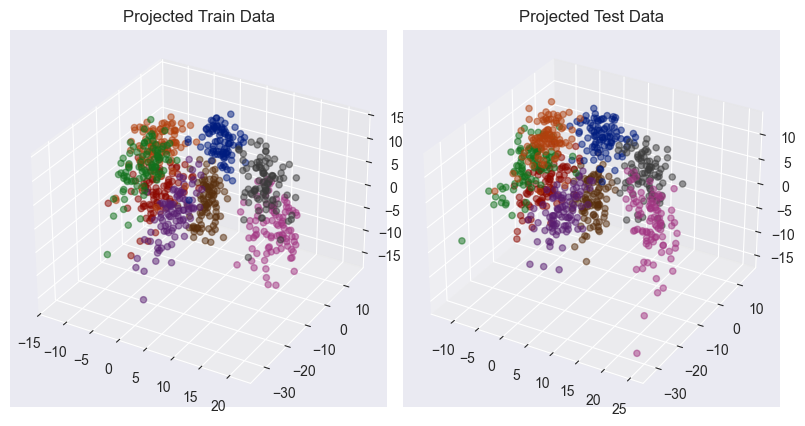

In [6]:
def visualize_projection_3d( projected_data_train,projected_data_test,label):
    """
    Visualize the projected low-dimensional data.

    Parameters:
    projected_data_train: The training data after dimensionality reduction.
    projected_data_test: The test data after dimensionality reduction.
    label: The angle label of data
    """
    
    fig = plt.figure(figsize=(8,8))
    # define color_set
    color_set = sns.color_palette('dark',n_colors=8)

    # Plot projected data
    
    ax = fig.add_subplot(121, projection='3d')
    # Assuming projected data has been reduced to 1D for simple visualization
    for angle in np.unique(label):
        mask = label == angle
        ax.scatter(projected_data_train[mask, 0], projected_data_train[mask, 1], projected_data_train[mask, 2], color=color_set[angle],alpha=0.5, label='Train Data')

    ax.set_title('Projected Train Data')
    ax = fig.add_subplot(122, projection='3d')
    # Assuming projected data has been reduced to 1D for simple visualization
    for angle in np.unique(label):
        mask = label == angle
        ax.scatter(projected_data_test[mask, 0], projected_data_test[mask, 1], projected_data_test[mask, 2], color=color_set[angle],alpha=0.5, label='Test Data')

    ax.set_title('Projected Test Data')

    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

pca = PCA(num_components=3)

pca.fit(train_data)

projected_data = pca.transform(train_data)


visualize_projection_3d( projected_data,pca.transform(test_data),label)



## **(10 pts)** Model selection

In the context of Principal Component Analysis (PCA), determining the optimal number of components often involves examining the explained variance. A useful technique is the ‘elbow method’, which analyzes the second derivative of the curve plotting cumulative variance against the number of components. The ‘elbow’ point in the curve, where the rate of increase in explained variance significantly diminishes, suggests the suitable number of components to retain. This method helps to balance between the simplicity of the model and the amount of variance captured, ensuring that the selected components offer the greatest explanatory power with the least redundancy.Please derive the 'elbow' point for the pca model before.

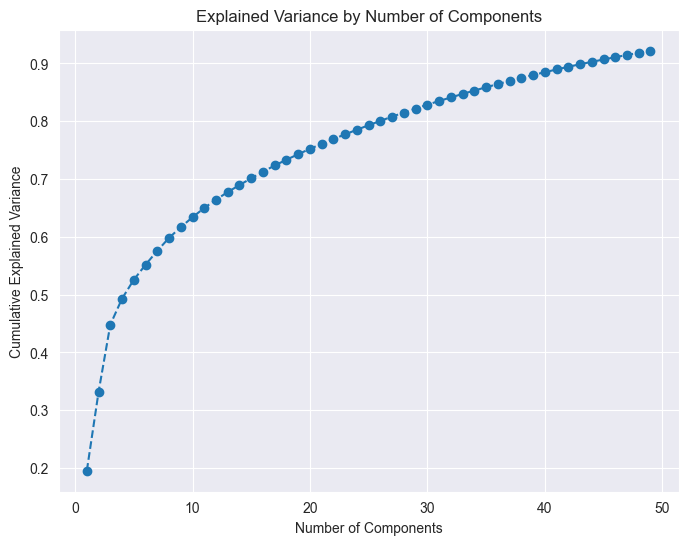

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def elbow_method(X,n_components):
    """
    Use the elbow method to determine the optimal number of principal components for PCA.

    Parameters:
    X: The input data matrix, where each row represents a sample.
    n_components: The number of components to show the explained variance

    Returns:
    optimal_num_components: Estimated optimal number of components from the elbow method visualization.
    """

    # Store explained variance ratios for different numbers of components
    explained_variances = []

    # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****


    # 1. Initialize PCA with the given number of components
    for k in range(1, n_components):
        # 1. Initialize PCA with the given number of components
        pca = PCA(k)

    # 2. Fit the PCA model with the data
        pca.fit(X)

    # 3. Append the cumulative explained variance ratio to the list
        cumulative_variance = np.sum(pca.explained_variance_ratio_)
        explained_variances.append(cumulative_variance)


    # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

    # Plot the explained variance to visualize the elbow point
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, n_components), explained_variances, marker='o', linestyle='--')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('Explained Variance by Number of Components')
    plt.grid(True)
    plt.show()

    return explained_variances


# Call the elbow method
explained_variances = elbow_method(train_data,50)


# Part 2. Probabilistic PCA 
In this part, you are tasked with implementing the Probabilistic Principal Component Analysis (PPCA) algorithm using the Expectation-Maximization (EM) method. PPCA extends the traditional PCA by incorporating a probabilistic model, which offers a robust framework for dealing with noise in data. In particular, PPCA assumes that the observed data are generated from a Gaussian distribution governed by latent variables. The EM algorithm is employed to estimate the parameters of this model iteratively.

Your challenge is to derive the EM algorithm's update rules, which consist of two main steps: the E-step (Expectation Step) and the M-step (Maximization Step). In the E-step, you should compute the expected values of the latent variables given the observed data and the current parameter estimates. Then, the M-step requires you to update the model parameters by maximizing the expected log-likelihood obtained from the E-step.


## **(15 pts)** PPCA update rules
Consider that the PPCA model assumes:

Each observed data point $ \mathbf{x}_n $ is associated with a latent variable $ \mathbf{z}_n $, and is generated as $ \mathbf{x}_n = \mathbf{W} \mathbf{z}_n + \boldsymbol{\mu} + \boldsymbol{\epsilon}_n $, where $ \boldsymbol{\epsilon}_n \sim \mathcal{N}(\mathbf{0}, \sigma^2\mathbf{I}) $.
Latent variables $ \mathbf{z}_n $ are drawn from a standard normal distribution: $ \mathcal{N}(\mathbf{0}, \mathbf{I}) $.
Your task is to start by deriving the mathematical expressions for the E-step and M-step updates. Use the given assumptions, and be prepared to iterate between these steps until convergence. Please provide the derivation of these formulas before proceeding with the implementation here

### E-Step:

In the Expectation-Maximization (EM) algorithm, the E-step involves calculating the expected value of the latent variables given the observed data and the current parameter estimates.

Given the generative model for the observed data$\mathbf{x}_n$:

$$
\mathbf{x}_n = \mathbf{W} \mathbf{z}_n + \boldsymbol{\mu} + \boldsymbol{\epsilon}_n
$$

where:
    \item$\mathbf{x}_n$is the observed vector,
    \item$\mathbf{z}_n$is the latent variable, which is drawn from a standard normal distribution:$\mathbf{z}_n \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$,
    \item$\boldsymbol{\epsilon}_n$is Gaussian noise,$\boldsymbol{\epsilon}_n \sim \mathcal{N}(0, \sigma^2 \mathbf{I})$,
    \item$\mathbf{W}$is the weight matrix,
    \item$\boldsymbol{\mu}$is the mean vector.

The goal of the E-step is to compute the posterior distribution of the latent variables given the observed data and the current parameter estimates.

By Bayes' theorem, the posterior distribution$p(\mathbf{z}_n | \mathbf{x}_n)$is given by:

$$
p(\mathbf{z}_n | \mathbf{x}_n) = \frac{p(\mathbf{x}_n | \mathbf{z}_n) p(\mathbf{z}_n)}{p(\mathbf{x}_n)}
$$

The marginal likelihood$p(\mathbf{x}_n)$serves as a normalizing constant that is often not computed explicitly.

1. Likelihood$p(\mathbf{x}_n | \mathbf{z}_n)$

Assuming the observed data given the latent variables follows a Gaussian distribution, we have:

$$
p(\mathbf{x}_n | \mathbf{z}_n) = \mathcal{N}(\mathbf{x}_n; \mathbf{W} \mathbf{z}_n + \boldsymbol{\mu}, \sigma^2 \mathbf{I})
$$

The probability density function can be expressed as:

$$
p(\mathbf{x}_n | \mathbf{z}_n) = \frac{1}{(2\pi)^{d/2} \sigma^d} \exp\left( -\frac{1}{2\sigma^2} \|\mathbf{x}_n - (\mathbf{W} \mathbf{z}_n + \boldsymbol{\mu})\|^2 \right)
$$

2. Prior$p(\mathbf{z}_n)$

The prior distribution for the latent variable is assumed to be:

$$
p(\mathbf{z}_n) = \mathcal{N}(\mathbf{z}_n; \mathbf{0}, \mathbf{I})
$$

The probability density function for the prior is:

$$
p(\mathbf{z}_n) = \frac{1}{(2\pi)^{k/2}} \exp\left( -\frac{1}{2} \|\mathbf{z}_n\|^2 \right)
$$

Combining Likelihood and Prior

Combining the likelihood and prior, we obtain:

$$
p(\mathbf{z}_n | \mathbf{x}_n) \propto p(\mathbf{x}_n | \mathbf{z}_n) p(\mathbf{z}_n)
$$

Substituting the expressions for the likelihood and prior results in:

$$
p(\mathbf{z}_n | \mathbf{x}_n) \propto \exp\left( -\frac{1}{2\sigma^2} \|\mathbf{x}_n - (\mathbf{W} \mathbf{z}_n + \boldsymbol{\mu})\|^2 - \frac{1}{2} \|\mathbf{z}_n\|^2 \right)
$$

Posterior Distribution Approximation

To simplify, we recognize that$p(\mathbf{z}_n | \mathbf{x}_n)$can be approximated as a Gaussian distribution:

$$
p(\mathbf{z}_n | \mathbf{x}_n) \sim \mathcal{N}(\boldsymbol{\mu}_n, \Sigma_n)
$$

where:
The covariance$\Sigma_n$is given by:
$$
\Sigma_n = \left( \frac{1}{\sigma^2} \mathbf{W}^T \mathbf{W} + \mathbf{I} \right)^{-1}
$$

The mean$\boldsymbol{\mu}_n$is given by:
$$
\boldsymbol{\mu}_n = \Sigma_n \left( \frac{1}{\sigma^2} \mathbf{W}^T (\mathbf{x}_n - \boldsymbol{\mu}) \right)
$$

Summary

In the E-step, we compute the posterior distribution of the latent variables$\mathbf{z}_n$given the observed data$\mathbf{x}_n$:

**Posterior Distribution**:
$$
p(\mathbf{z}_n | \mathbf{x}_n) \sim \mathcal{N}(\boldsymbol{\mu}_n, \Sigma_n)
$$

**Mean**:
$$
\boldsymbol{\mu}_n = \Sigma_n \left( \frac{1}{\sigma^2} \mathbf{W}^T (\mathbf{x}_n - \boldsymbol{\mu}) \right)
$$

**Covariance**:
$$
\Sigma_n = \left( \frac{1}{\sigma^2} \mathbf{W}^T \mathbf{W} + \mathbf{I} \right)^{-1}
$$

This information will be utilized in the subsequent M-step to update the model parameters.

### M-Step:

In the Expectation-Maximization (EM) algorithm, the M-step involves maximizing the expected complete-data log-likelihood obtained during the E-step with respect to the model parameters. In this context, we aim to update the parameters$\mathbf{W}$,$\boldsymbol{\mu}$, and$\sigma^2$.

Expected Complete Data Log-Likelihood

From the E-step, we have computed the posterior distribution$p(\mathbf{z}_n | \mathbf{x}_n)$. The expected complete-data log-likelihood can be expressed as:

$$
Q(\mathbf{W}, \boldsymbol{\mu}, \sigma^2) = \mathbb{E}_{p(\mathbf{z} | \mathbf{x}; \mathbf{W}, \boldsymbol{\mu}, \sigma^2)} \left[ \log p(\mathbf{x}, \mathbf{z} | \mathbf{W}, \boldsymbol{\mu}, \sigma^2) \right]
$$

This can be expanded as:

$$
Q(\mathbf{W}, \boldsymbol{\mu}, \sigma^2) = \sum_{n=1}^{N} \mathbb{E}_{p(\mathbf{z}_n | \mathbf{x}_n; \mathbf{W}, \boldsymbol{\mu}, \sigma^2)} \left[ \log p(\mathbf{x}_n | \mathbf{z}_n, \mathbf{W}, \boldsymbol{\mu}, \sigma^2) + \log p(\mathbf{z}_n) \right]
$$

By breaking down the terms, we interpret the first term as the likelihood of the observed data given the latent variables, and the second term as the prior over the latent variables.

Maximizing the Expected Log-Likelihood

### 1. Update for$\mathbf{W}$To update the weight matrix$\mathbf{W}$, we maximize$Q$with respect to$\mathbf{W}$:

$$
\frac{\partial Q}{\partial \mathbf{W}} = 0
$$

Substituting the expressions for the likelihood and prior yields:

$$
\frac{\partial}{\partial \mathbf{W}} \sum_{n=1}^{N} \mathbb{E}_{p(\mathbf{z}_n | \mathbf{x}_n)} \left[ \log p(\mathbf{x}_n | \mathbf{z}_n, \mathbf{W}, \boldsymbol{\mu}, \sigma^2) \right] = 0
$$

This typically leads to a system of equations that can be solved for$\mathbf{W}$.

### 2. Update for$\boldsymbol{\mu}$Next, we update the mean vector$\boldsymbol{\mu}$:

$$
\frac{\partial Q}{\partial \boldsymbol{\mu}} = 0
$$

This can similarly be maximized by setting the gradient of$Q$with respect to$\boldsymbol{\mu}$to zero, leading to an update rule of the form:

$$
\boldsymbol{\mu} = \frac{1}{N} \sum_{n=1}^{N} \mathbb{E}_{p(\mathbf{z}_n | \mathbf{x}_n)} [\mathbf{W} \mathbf{z}_n]
$$

### 3. Update for$\sigma^2$The noise variance$\sigma^2$can also be updated:

$$
\frac{\partial Q}{\partial \sigma^2} = 0
$$

The update rule for$\sigma^2$can generally be derived as follows:

$$
\sigma^2 = \frac{1}{dN} \sum_{n=1}^{N} \mathbb{E}_{p(\mathbf{z}_n | \mathbf{x}_n)} \left[ \|\mathbf{x}_n - (\mathbf{W} \mathbf{z}_n + \boldsymbol{\mu})\|^2 \right]
$$

Summary of the Updates

From the above steps, we obtain the updated parameters for the M-step:

**Update for$\mathbf{W}$**:
$$
\mathbf{W} \text{ is updated by solving } \frac{\partial Q}{\partial \mathbf{W}} = 0
$$

**Update for$\boldsymbol{\mu}$**:
$$
\boldsymbol{\mu} = \frac{1}{N} \sum_{n=1}^{N} \mathbb{E}_{p(\mathbf{z}_n | \mathbf{x}_n)} [\mathbf{W} \mathbf{z}_n]
$$

**Update for$\sigma^2$**:
$$
\sigma^2 = \frac{1}{dN} \sum_{n=1}^{N} \mathbb{E}_{p(\mathbf{z}_n | \mathbf{x}_n)} \left[ \|\mathbf{x}_n - (\mathbf{W} \mathbf{z}_n + \boldsymbol{\mu})\|^2 \right]
$$

These updates are iteratively applied, alternating between the E-step and the M-step, until convergence is achieved.


## **(40 pts)** PPCA algorithm

In [35]:
class PPCA:
    """
    Implement the PPCA algorithm to reduce the dimensionality of data X to num_components.

    Parameters:
    - num_components (int): The number of principal components to retain.

    Attributes:
    - num_components (int): Number of principal components.
    - W (numpy.ndarray): Projection matrix.
    - sigma2 (float): Variance of the noise.
    """

    def __init__(self, num_components):
        self.num_components = num_components
        self.W = None
        self.sigma2 = None

    def fit(self, X, tol=1e-4, max_iter=100):
        """
        Fit the PPCA model to the data X.

        Parameters:
        - X (numpy.ndarray): The input data matrix, where each row represents a sample.
        - tol (float): The convergence tolerance for the EM algorithm.
        - max_iter (int): The maximum number of iterations for the EM algorithm.
        """

        W_new = None
        sigma2_new = None
        W = None
        # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
        if X.ndim > 2:
            X = X.reshape(X.shape[0], -1)

        # 1. Standardize the data: Subtract the mean from each feature.
        X_mean = np.mean(X, axis=0)
        X_centered = X - X_mean

        num_samples, num_features = X_centered.shape
        W = np.random.rand(num_features, self.num_components)
        sigma2 = 1.0

        # 2. Initialize W and sigma2 randomly.

        for _ in range(max_iter):
            # E-step: Compute expected values of latent variables.
            WTW_plus_sigma2I_inv = np.linalg.inv(W.T @ W + sigma2 * np.eye(self.num_components))
            E_Z = X_centered @ W @ WTW_plus_sigma2I_inv

            # M-step: Update W and sigma2.
            W_new = (X_centered.T @ E_Z) @ np.linalg.inv(E_Z.T @ E_Z + sigma2 * np.eye(self.num_components))
            error = X_centered - E_Z @ W_new.T
            sigma2_new = np.sum(np.linalg.norm(error, axis=1) ** 2) / (num_samples * num_features)

            # Check convergence.
            if (np.linalg.norm(W_new - W, ord='fro') < tol and
                    np.abs(sigma2_new - sigma2) < tol):
                break

            W = W_new
            sigma2 = sigma2_new

        self.W = W
        self.sigma2 = sigma2

        # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

    def transform(self, X):
        """
        Project the data X onto the reduced space.

        Parameters:
        - X (numpy.ndarray): The input data matrix, where each row represents a sample.

        Returns:
        - projected_data (numpy.ndarray): The projected data in the reduced-dimensional space.
        """
        projected_data = None
        # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
        if X.ndim > 2:
            X = X.reshape(X.shape[0], -1)
        X_mean = np.mean(X, axis=0)
        X_centered = X - X_mean
        projected_data = X_centered @ self.W  # Project data onto W
        # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
        return projected_data

# Example usage:
ppca = PPCA(num_components=2)
ppca.fit(train_data)  # Ensure train_data is appropriate for fitting
projected_data_ppca = ppca.transform(train_data)  # Transform the data to lower dimension

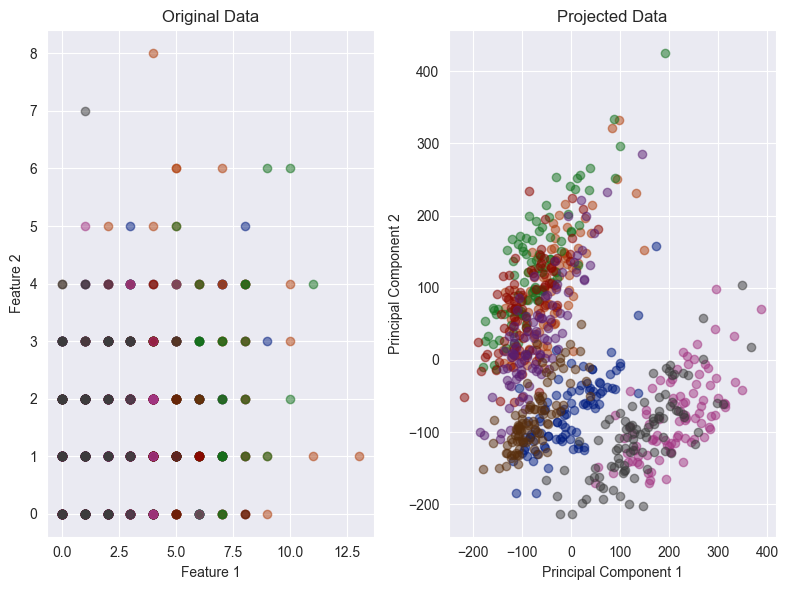

In [28]:
visualize_projection(train_data, projected_data_ppca,label)

## **(Bonus 5 pts)** Viualization for PPCA
Please observe the data distribution of PPCA and PCA after dimensionality reduction, which one is better? Give your opinion:

Hint: You can run the PPCA code a few more times to get a different result

**Opinions:** My opinion is PCCA is better. The probabilistic properties provided by PPCA and its adaptability to signal noise and missing values make it better than PCA.

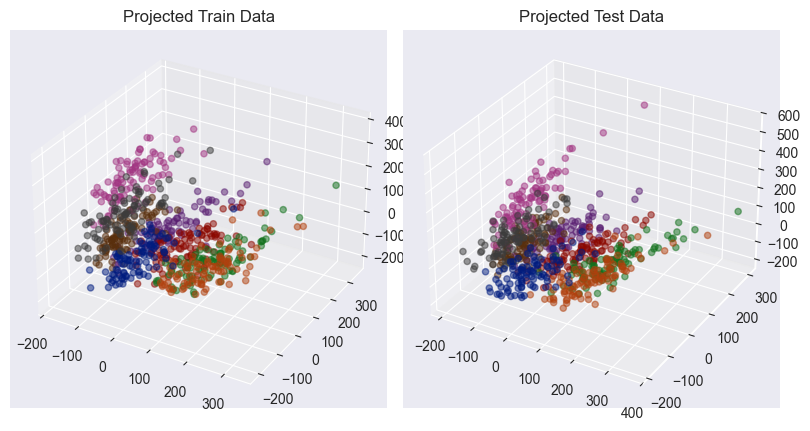

In [10]:

ppca = PPCA(num_components=3)
ppca.fit(train_data)
projected_data_ppca = ppca.transform(train_data)

visualize_projection_3d( projected_data_ppca,ppca.transform(test_data),label)